<a href="https://colab.research.google.com/github/SAINIDHI2005/Bluetooth-RC-Car---STM32/blob/main/ids_gcn_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/SAINIDHI2005/GNN_IDS_Dataset.git

Cloning into 'GNN_IDS_Dataset'...
remote: Enumerating objects: 350, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 350 (delta 0), reused 0 (delta 0), pack-reused 347 (from 1)
Receiving objects: 100% (350/350), 1021.00 MiB | 22.42 MiB/s, done.
Resolving deltas: 100% (219/219), done.
Updating files: 100% (311/311), done.


In [2]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 908.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.6 MB/s eta 0:00:00


In [3]:
import os
import random

import pandas as pd
import numpy as np

import torch
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import kneighbors_graph
from sklearn.feature_selection import VarianceThreshold

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
DATASET_PATH = "GNN_IDS_Dataset/CSV"

In [5]:
LABEL_MAP = {

    "BENIGN": 0,

    # DDoS
    "DDOS-ACK_FRAGMENTATION": 1,
    "DDOS-HTTP_FLOOD": 1,
    "DDOS-ICMP_FLOOD": 1,
    "DDOS-ICMP_FRAGMENTATION": 1,
    "DDOS-PSHACK_FLOOD": 1,
    "DDOS-RSTFINFLOOD": 1,
    "DDOS-SLOWLORIS": 1,
    "DDOS-SYN_FLOOD": 1,
    "DDOS-SYNONYMOUSIP_FLOOD": 1,
    "DDOS-TCP_FLOOD": 1,
    "DDOS-UDP_FLOOD": 1,
    "DDOS-UDP_FRAGMENTATION": 1,

    # DoS
    "DOS-HTTP_FLOOD": 2,
    "DOS-SYN_FLOOD": 2,
    "DOS-TCP_FLOOD": 2,
    "DOS-UDP_FLOOD": 2,

    # Mirai
    "MIRAI-GREETH_FLOOD": 3,
    "MIRAI-GREIP_FLOOD": 3,
    "MIRAI-UDPPLAIN": 3,

    # Recon
    "RECON-HOSTDISCOVERY": 4,
    "RECON-OSSCAN": 4,
    "RECON-PINGSWEEP": 4,
    "RECON-PORTSCAN": 4,
    "VULNERABILITYSCAN": 4,

    # Spoofing
    "DNS_SPOOFING": 5,
    "MITM-ARPSPOOFING": 5,
}

In [6]:
FOLDER_TO_ATTACK = {

    "Benign_Final": "BENIGN",

    "DDoS-ACK_Fragmentation": "DDOS-ACK_FRAGMENTATION",
    "DDoS-HTTP_Flood": "DDOS-HTTP_FLOOD",
    "DDoS-ICMP_Flood": "DDOS-ICMP_FLOOD",
    "DDoS-ICMP_Fragmentation": "DDOS-ICMP_FRAGMENTATION",
    "DDoS-PSHACK_FLOOD": "DDOS-PSHACK_FLOOD",
    "DDoS-RSTFINFLOOD": "DDOS-RSTFINFLOOD",
    "DDoS-SlowLoris": "DDOS-SLOWLORIS",
    "DDoS-SYN_Flood": "DDOS-SYN_FLOOD",
    "DDoS-SynonymousIP_Flood": "DDOS-SYNONYMOUSIP_FLOOD",
    "DDoS-TCP_Flood": "DDOS-TCP_FLOOD",
    "DDoS-UDP_Flood": "DDOS-UDP_FLOOD",
    "DDoS-UDP_Fragmentation": "DDOS-UDP_FRAGMENTATION",

    "DoS-HTTP_Flood": "DOS-HTTP_FLOOD",
    "DoS-SYN_Flood": "DOS-SYN_FLOOD",
    "DoS-TCP_Flood": "DOS-TCP_FLOOD",
    "DoS-UDP_Flood": "DOS-UDP_FLOOD",

    "Mirai-greeth_flood": "MIRAI-GREETH_FLOOD",
    "Mirai-greip_flood": "MIRAI-GREIP_FLOOD",
    "Mirai-udpplain": "MIRAI-UDPPLAIN",

    "Recon-HostDiscovery": "RECON-HOSTDISCOVERY",
    "Recon-OSScan": "RECON-OSSCAN",
    "Recon-PingSweep": "RECON-PINGSWEEP",
    "Recon-PortScan": "RECON-PORTSCAN",
    "VulnerabilityScan": "VULNERABILITYSCAN",

    "DNS_Spoofing": "DNS_SPOOFING",
    "MITM-ArpSpoofing": "MITM-ARPSPOOFING",
}

In [7]:
SAMPLES_PER_FILE = 15000

all_dfs = []

for folder_name, attack_name in FOLDER_TO_ATTACK.items():

    label = LABEL_MAP[attack_name]

    class_path = os.path.join(
        DATASET_PATH,
        folder_name
    )

    files = os.listdir(class_path)

    for file in files:

        if not file.endswith(".csv"):
            continue

        file_path = os.path.join(
            class_path,
            file
        )

        print("Loading:", file_path)

        df = pd.read_csv(file_path)

        sample_size = min(
            SAMPLES_PER_FILE,
            len(df)
        )

        df = df.sample(
            sample_size,
            random_state=42
        )

        df["Label"] = label

        all_dfs.append(df)

Loading: GNN_IDS_Dataset/CSV/Benign_Final/BenignTraffic.pcap.csv
Loading: GNN_IDS_Dataset/CSV/Benign_Final/BenignTraffic2.pcap.csv
Loading: GNN_IDS_Dataset/CSV/Benign_Final/BenignTraffic1.pcap.csv
Loading: GNN_IDS_Dataset/CSV/Benign_Final/BenignTraffic3.pcap.csv
Loading: GNN_IDS_Dataset/CSV/DDoS-ACK_Fragmentation/DDoS-ACK_Fragmentation4.pcap.csv
Loading: GNN_IDS_Dataset/CSV/DDoS-ACK_Fragmentation/DDoS-ACK_Fragmentation2.pcap.csv
Loading: GNN_IDS_Dataset/CSV/DDoS-ACK_Fragmentation/DDoS-ACK_Fragmentation7.pcap.csv
Loading: GNN_IDS_Dataset/CSV/DDoS-ACK_Fragmentation/DDoS-ACK_Fragmentation8.pcap.csv
Loading: GNN_IDS_Dataset/CSV/DDoS-ACK_Fragmentation/DDoS-ACK_Fragmentation10.pcap.csv
Loading: GNN_IDS_Dataset/CSV/DDoS-ACK_Fragmentation/DDoS-ACK_Fragmentation.pcap.csv
Loading: GNN_IDS_Dataset/CSV/DDoS-ACK_Fragmentation/DDoS-ACK_Fragmentation9.pcap.csv
Loading: GNN_IDS_Dataset/CSV/DDoS-ACK_Fragmentation/DDoS-ACK_Fragmentation11.pcap.csv
Loading: GNN_IDS_Dataset/CSV/DDoS-ACK_Fragmentation/DDoS

In [8]:
df = pd.concat(
    all_dfs,
    ignore_index=True
)

print(df.shape)

(4508735, 40)


In [9]:
X = df.drop(columns=["Label"])

y = df["Label"]

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [13]:
# Convert everything to numeric

X_train = pd.DataFrame(X_train).apply(
    pd.to_numeric,
    errors='coerce'
)

X_val = pd.DataFrame(X_val).apply(
    pd.to_numeric,
    errors='coerce'
)

X_test = pd.DataFrame(X_test).apply(
    pd.to_numeric,
    errors='coerce'
)

# Replace inf values

X_train.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

X_val.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

X_test.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

# Fill NaN values

X_train.fillna(0, inplace=True)

X_val.fillna(0, inplace=True)

X_test.fillna(0, inplace=True)

print("Cleaning complete")

Cleaning complete


In [14]:
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [15]:
selector = VarianceThreshold(
    threshold=0.01
)

X_train = selector.fit_transform(X_train)

X_val = selector.transform(X_val)

X_test = selector.transform(X_test)

In [16]:
GRAPH_SIZE = 1000
K = 5

In [17]:
def create_graph_dataset(X, y):

    graphs = []

    total_samples = len(X)

    num_graphs = total_samples // GRAPH_SIZE

    for i in range(num_graphs):

        start = i * GRAPH_SIZE
        end = start + GRAPH_SIZE

        X_chunk = X[start:end]

        y_chunk = y.iloc[start:end]

        A = kneighbors_graph(
            X_chunk,
            n_neighbors=K,
            mode='distance',
            metric='cosine',
            include_self=False
        )

        edge_index = torch.tensor(
            np.array(A.nonzero()),
            dtype=torch.long
        )

        edge_weight = torch.tensor(
            A.data,
            dtype=torch.float
        )

        x_tensor = torch.tensor(
            X_chunk,
            dtype=torch.float
        )

        y_tensor = torch.tensor(
            y_chunk.values,
            dtype=torch.long
        )

        data = Data(
            x=x_tensor,
            edge_index=edge_index,
            edge_weight=edge_weight,
            y=y_tensor
        )

        graphs.append(data)

        print(f"Graph {i+1}/{num_graphs} created")

    return graphs

In [18]:
train_graphs = create_graph_dataset(
    X_train,
    y_train
)

val_graphs = create_graph_dataset(
    X_val,
    y_val
)

test_graphs = create_graph_dataset(
    X_test,
    y_test
)

Graph 1/3156 created
Graph 2/3156 created
Graph 3/3156 created
Graph 4/3156 created
Graph 5/3156 created
Graph 6/3156 created
Graph 7/3156 created
Graph 8/3156 created
Graph 9/3156 created
Graph 10/3156 created
Graph 11/3156 created
Graph 12/3156 created
Graph 13/3156 created
Graph 14/3156 created
Graph 15/3156 created
Graph 16/3156 created
Graph 17/3156 created
Graph 18/3156 created
Graph 19/3156 created
Graph 20/3156 created
Graph 21/3156 created
Graph 22/3156 created
Graph 23/3156 created
Graph 24/3156 created
Graph 25/3156 created
Graph 26/3156 created
Graph 27/3156 created
Graph 28/3156 created
Graph 29/3156 created
Graph 30/3156 created
Graph 31/3156 created
Graph 32/3156 created
Graph 33/3156 created
Graph 34/3156 created
Graph 35/3156 created
Graph 36/3156 created
Graph 37/3156 created
Graph 38/3156 created
Graph 39/3156 created
Graph 40/3156 created
Graph 41/3156 created
Graph 42/3156 created
Graph 43/3156 created
Graph 44/3156 created
Graph 45/3156 created
Graph 46/3156 creat

In [19]:
train_loader = DataLoader(
    train_graphs,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    val_graphs,
    batch_size=4
)

test_loader = DataLoader(
    test_graphs,
    batch_size=4
)

In [20]:
class GraphSAGE(torch.nn.Module):

    def __init__(self, in_channels, hidden_channels, num_classes):

        super().__init__()

        self.conv1 = SAGEConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = SAGEConv(
            hidden_channels,
            hidden_channels
        )

        self.fc = torch.nn.Linear(
            hidden_channels,
            num_classes
        )

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index

        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.3,
            training=self.training
        )

        x = self.conv2(
            x,
            edge_index
        )

        x = F.relu(x)

        x = self.fc(x)

        return x

In [21]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

model = GraphSAGE(
    in_channels=X_train.shape[1],
    hidden_channels=64,
    num_classes=6
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

criterion = torch.nn.CrossEntropyLoss()

In [23]:
EPOCHS = 30

train_losses = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        out = model(batch)

        loss = criterion(
            out,
            batch.y
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(
        f"Epoch {epoch+1} | Loss: {avg_loss:.4f}"
    )

Epoch 1 | Loss: 8.5220
Epoch 2 | Loss: 5.6753
Epoch 3 | Loss: 3.4585
Epoch 4 | Loss: 4.5746
Epoch 5 | Loss: 2.6423
Epoch 6 | Loss: 2.5699
Epoch 7 | Loss: 2.0742
Epoch 8 | Loss: 1.0725
Epoch 9 | Loss: 0.7702
Epoch 10 | Loss: 0.7367
Epoch 11 | Loss: 0.2797
Epoch 12 | Loss: 0.4197
Epoch 13 | Loss: 0.3978
Epoch 14 | Loss: 0.3758
Epoch 15 | Loss: 0.3800
Epoch 16 | Loss: 0.2239
Epoch 17 | Loss: 0.3499
Epoch 18 | Loss: 0.2345
Epoch 19 | Loss: 0.2338
Epoch 20 | Loss: 0.2601
Epoch 21 | Loss: 0.2148
Epoch 22 | Loss: 0.2146
Epoch 23 | Loss: 0.2371
Epoch 24 | Loss: 0.2316
Epoch 25 | Loss: 0.2185
Epoch 26 | Loss: 0.2287
Epoch 27 | Loss: 0.2227
Epoch 28 | Loss: 0.2102
Epoch 29 | Loss: 0.3186
Epoch 30 | Loss: 0.2134


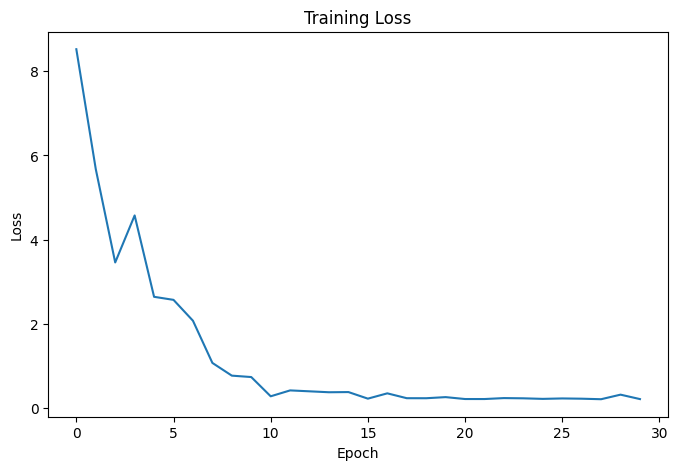

In [24]:
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.show()

In [27]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(device)

        out = model(batch)

        pred = out.argmax(dim=1)

        all_preds.extend(
            pred.cpu().numpy()
        )

        all_labels.extend(
            batch.y.cpu().numpy()
        )

accuracy = accuracy_score(
    all_labels,
    all_preds
)

print("Accuracy:", accuracy)

Accuracy: 0.8999585798816568


In [29]:
target_names = [
    "Benign",
    "DDoS",
    "DoS",
    "Mirai",
    "Recon",
    "Spoofing"
]

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=target_names
    )
)

              precision    recall  f1-score   support

      Benign       0.70      0.78      0.74      8998
        DDoS       0.89      0.96      0.92    394993
         DoS       0.71      0.49      0.58     85454
       Mirai       1.00      1.00      1.00    170474
       Recon       0.78      0.75      0.77      9335
    Spoofing       0.85      0.76      0.80      6746

    accuracy                           0.90    676000
   macro avg       0.82      0.79      0.80    676000
weighted avg       0.89      0.90      0.89    676000



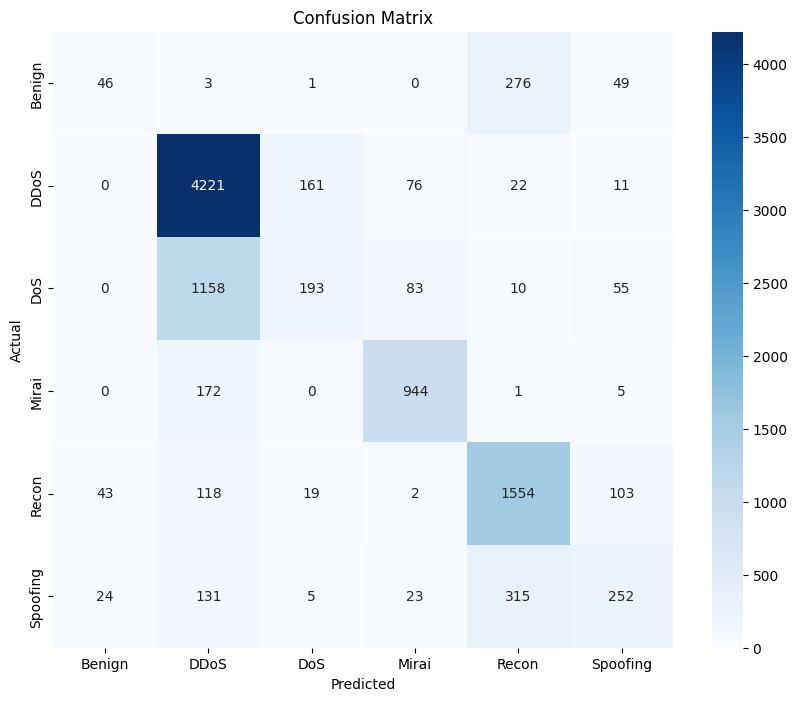

In [ ]:
cm = confusion_matrix(
    test_graph.y.cpu(),
    pred.cpu()
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()